In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [80]:
import cassiopeia as cass
from cassiopeia.data import Queue, Side
from cassiopeia.core import Match, Summoner
from cassiopeia.core.match import Participant, Team

from typing import List


In [53]:
import enum
from datetime import datetime, timezone


TIME_FORMAT = r"%B %d, %Y %I:%M:%S %p"

class Season(enum.Enum):
    S14_3 = "S14_3"
    S14_2 = "S14_2"
    S14_1 = "S14_1"
    S14 = "S14"

SEASON_BOUNDS = {
    Season.S14_3: (datetime.strptime('September 25, 2024 12:00:00 AM', TIME_FORMAT).replace(tzinfo=timezone.utc), datetime.strptime('January 08, 2025 11:59:59 PM', TIME_FORMAT).replace(tzinfo=timezone.utc)),
    Season.S14_2: (datetime.strptime('May 15, 2024 12:00:00 AM', TIME_FORMAT).replace(tzinfo=timezone.utc), datetime.strptime('September 24, 2024 11:59:59 PM', TIME_FORMAT).replace(tzinfo=timezone.utc)),
    Season.S14_1: (datetime.strptime('January 10, 2024 12:00:00 AM', TIME_FORMAT).replace(tzinfo=timezone.utc), datetime.strptime('May 14, 2024 11:59:59 PM', TIME_FORMAT).replace(tzinfo=timezone.utc)),
    Season.S14: (datetime.strptime('January 10, 2024 12:00:00 AM', TIME_FORMAT).replace(tzinfo=timezone.utc), datetime.strptime('January 08, 2025 11:59:59 PM', TIME_FORMAT).replace(tzinfo=timezone.utc)),
}

In [88]:
class Player:
    id: str
    names: List[str]
    summoners: List[Summoner]

    def __init__(self, id: str, names: List[str]):
        self.id = id
        self.names = names
        summoners = []
        for name in names:
            account = cass.get_account(name=name.split("#")[0], tagline=name.split("#")[1], region="EUW")
            summoners.append(account.summoner)
        self.summoners = summoners

    def __str__(self):
        return self.id

    def __repr__(self):
        return self.id
        

class Players:
    players: List[Player]

    def __init__(self, players: List[Player]):
        self.players = players

    def get_all_names(self) -> List[str]:
        return [name for player in self.players for name in player.names]

In [89]:
ANDREAS = Player(id="Andreas", names=["Critchard#117", "snoop taff#177"])
FELIX = Player(id="Felix", names=["MaBalls#EUW"])
FURB = Player(id="Furb", names=["Leigh#EUW"])
JAKE = Player(id="Jake", names=["jakegt1#EUW"])
JAY = Player(id="Jay", names=["Jay#VFG4"])
JORDAN = Player(id="Jordan", names=["Xordania#EUW"])
LAUREL = Player(id="Laurel", names=["Birbo#birbo"])
MINZ = Player(id="Minz", names=["rub of the rift#golf", "小狼啊#nmsl", "01554#SA14"])
RICH = Player(id="Rich", names=["Sourbutts#urmum", "Smelly Fingers#brown", "Wyn#cath"])
SEAN = Player(id="Sean", names=["Wyn#JNS"])
WYN = Player(id="Wyn", names=["Wyn#EUW", "Fearyman#Minz"])

Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/Critchard/117
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/snoop%20taff/177
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/MaBalls/EUW
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/Leigh/EUW
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/jakegt1/EUW
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/Jay/VFG4
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/Xordania/EUW
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/Birbo/birbo
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/rub%20of%20the%20rift/golf
Making call: https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/小狼啊/nmsl
Making call: https://europe.api.riotgames.com

In [313]:
# ALL_PLAYERS = [ANDREAS, FELIX, FURB, JAKE, JAY, JORDAN, LAUREL, MINZ, RICH, SEAN, WYN]
ALL_PLAYERS = [ANDREAS, FELIX, FURB, JAKE, JAY, JORDAN, MINZ, RICH, SEAN, WYN]
MOST_FREQUENT_PLAYERS = [ANDREAS, FELIX, JAY, MINZ, RICH, WYN]
TEST_PLAYERS = [FELIX]

In [317]:
NAME_TO_PLAYER = {
    "Critchard#117": ANDREAS,
    "snoop taff#177": ANDREAS,
    "MaBalls#EUW": FELIX,
    "Leigh#EUW": FURB,
    "jakegt1#EUW": JAKE,
    "Jay#VFG4": JAY,
    "Xordania#EUW": JORDAN,
    "Birbo#birbo": LAUREL,
    "rub of the rift#golf": MINZ,
    "小狼啊#nmsl": MINZ,
    "01554#SA14": MINZ,
    "Sourbutts#urmum": RICH,
    "Smelly Fingers#brown": RICH,
    "Wyn#cath": RICH,
    "Wyn#JNS": SEAN,
    "Wyn#EUW": WYN,
    "Fearyman#Minz": WYN,
}
ID_TO_PLAYER = {}
for player in ALL_PLAYERS:
    for summ in player.summoners:
        ID_TO_PLAYER[summ.id] = player

In [48]:
def get_matches_for_player(player: Player) -> List[Match]:
    matches = []
    for summoner in player.summoners:
        matches += list(cass.get_match_history(
            continent=summoner.region.continent,
            puuid=summoner.puuid,
            queue=Queue.ranked_flex_fives,
        ))
        matches += list(cass.get_match_history(
            continent=summoner.region.continent,
            puuid=summoner.puuid,
            queue=Queue.ranked_flex_threes,
        ))
    return matches

In [179]:
def filter_matches_containing_players(matches: List[Match], players: Players, season: Season):
    filtered_matches = []
    for match in matches:
        count = 0
        if not SEASON_BOUNDS[season][0] < match.start < SEASON_BOUNDS[season][1]:
            break
        participants = [participant.summoner.id for participant in match.participants]
        for player in players:
            for summoner in player.summoners:
                if summoner.id in participants:
                    count +=1
                    break
        if count >= min(3, len(players)):
            filtered_matches.append(match)
    return filtered_matches



In [180]:
def find_common_flex_games(players: Players, season: Season):
    matches_by_name = {player.id: get_matches_for_player(player=player) for player in players}
    matches_by_name = {key: filter_matches_containing_players(matches=val, players=players, season=season) for key, val in matches_by_name.items()}
    all_matches: List[Match] = sum(matches_by_name.values(), [])
    return list(set(all_matches))
    

In [ ]:
s14_3_matches = find_common_flex_games(ALL_PLAYERS, season=Season.S14_3)
s14_2_matches = find_common_flex_games(ALL_PLAYERS, season=Season.S14_2)
s14_1_matches = find_common_flex_games(ALL_PLAYERS, season=Season.S14_1)
s14_matches = find_common_flex_games(ALL_PLAYERS, season=Season.S14)


Making call: https://europe.api.riotgames.com/lol/match/v5/matches/by-puuid/mpDK2V_oR4G5pZfiNnfPI6Y4-4vXrbtM-OUaezso0XMgqMr1ojoK-AeawH3yPu3mICVLRZP-cmKgQg/ids?start=0&count=100&queue=440
Making call: https://europe.api.riotgames.com/lol/match/v5/matches/by-puuid/mpDK2V_oR4G5pZfiNnfPI6Y4-4vXrbtM-OUaezso0XMgqMr1ojoK-AeawH3yPu3mICVLRZP-cmKgQg/ids?start=100&count=100&queue=440
Making call: https://europe.api.riotgames.com/lol/match/v5/matches/by-puuid/mpDK2V_oR4G5pZfiNnfPI6Y4-4vXrbtM-OUaezso0XMgqMr1ojoK-AeawH3yPu3mICVLRZP-cmKgQg/ids?start=0&count=100&queue=470
Making call: https://europe.api.riotgames.com/lol/match/v5/matches/by-puuid/SZyJk5gcZ_PK_hXaA4RTpUVib41cUc4DmJS1MOST2VKEWgI_C83K_q-DC2N06sEf50umIbUU9Ztl0Q/ids?start=0&count=100&queue=440
Making call: https://europe.api.riotgames.com/lol/match/v5/matches/by-puuid/SZyJk5gcZ_PK_hXaA4RTpUVib41cUc4DmJS1MOST2VKEWgI_C83K_q-DC2N06sEf50umIbUU9Ztl0Q/ids?start=0&count=100&queue=470
Making call: https://europe.api.riotgames.com/lol/match/v5/matc

In [203]:
s14_3_matches = a

In [142]:
len(s14_matches)

359

In [197]:
def get_win_loss_stats_for_matches(matches: List[Match]):
    wins_by_player = {p: 0 for p in ALL_PLAYERS}
    games_by_player = {p: 0 for p in ALL_PLAYERS}
    all_ids = [summoner.id for player in ALL_PLAYERS for summoner in player.summoners]
    for match in matches:
        match: Match
        participants: List[Participant] = match.participants
        for participant in participants:
            if participant.summoner.id in all_ids:
                side = participant.side
                break
        team = match.blue_team if side == Side.blue else match.red_team
        for participant in team.participants:
            if participant.summoner.id not in ID_TO_PLAYER:
                break
            player = ID_TO_PLAYER[participant.summoner.id]
            games_by_player[player] += 1
            if team.win:
                wins_by_player[player] += 1

    wr_by_player = {p: wins_by_player[p] / games_by_player[p] for p in ALL_PLAYERS if games_by_player[p] > 0}

    return wins_by_player, games_by_player, wr_by_player


In [204]:
s14_wins_by_player, s14_games_by_player, s14_wr_by_player = get_win_loss_stats_for_matches(s14_matches)
s14_2_wins_by_player, s14_2_games_by_player, s14_2_wr_by_player = get_win_loss_stats_for_matches(s14_2_matches)
s14_3_wins_by_player, s14_3_games_by_player, s14_3_wr_by_player = get_win_loss_stats_for_matches(s14_3_matches)

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = [11, 7]
plt.rcParams['font.size'] = 14

In [206]:
def create_win_loss_plot(wins_by_player, games_by_player):
        players = [str(p) for p in ALL_PLAYERS]

        sorted_wins = [wins_by_player[p] for p in ALL_PLAYERS]
        sorted_losses = [-(games_by_player[p] - wins_by_player[p]) for p in ALL_PLAYERS]
        sorted_net_wins = [w + l for w, l in zip(sorted_wins, sorted_losses)]
        players_ordered_by_net_wins = sorted(players, key=lambda x: sorted_net_wins[players.index(x)])
        bar_data = {'W/L': ['Win'] * len(ALL_PLAYERS) + ['Loss'] * len(ALL_PLAYERS),
                'Games': sorted_wins + sorted_losses,
                'Player': ALL_PLAYERS + ALL_PLAYERS}
        ax = sns.barplot(data=bar_data, x='Player', y='Games', hue='W/L', dodge=False, palette='turbo', order=players_ordered_by_net_wins)
        ax.axhline(0, lw=2, color='black')

        ax2 = ax.twinx()
        line_data = {
                'Net Wins': sorted(sorted_net_wins),
                'Player': [str(p) for p in ALL_PLAYERS]
        }
        sns.lineplot(data=line_data['Net Wins'], marker='o', ax=ax2, linestyle='')
        ax2.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1])

        plt.show()


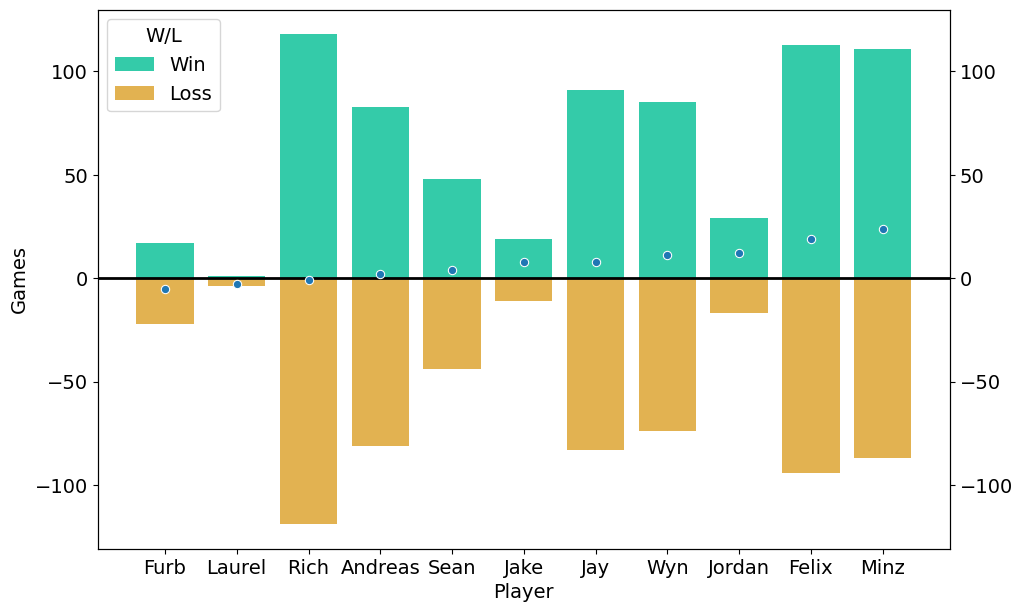

In [207]:
create_win_loss_plot(s14_wins_by_player, s14_games_by_player)

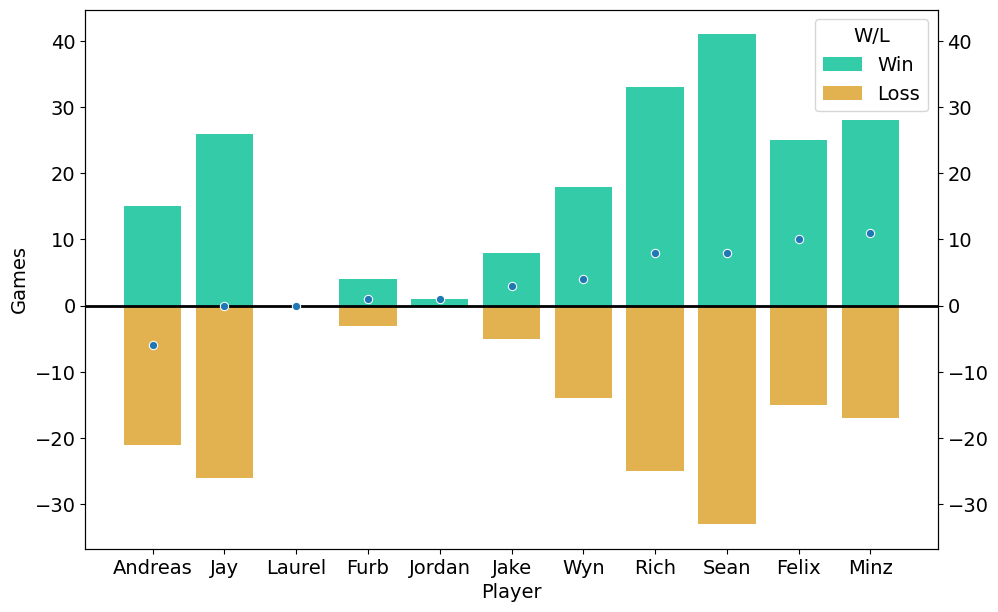

In [210]:
create_win_loss_plot(s14_2_wins_by_player, s14_2_games_by_player)

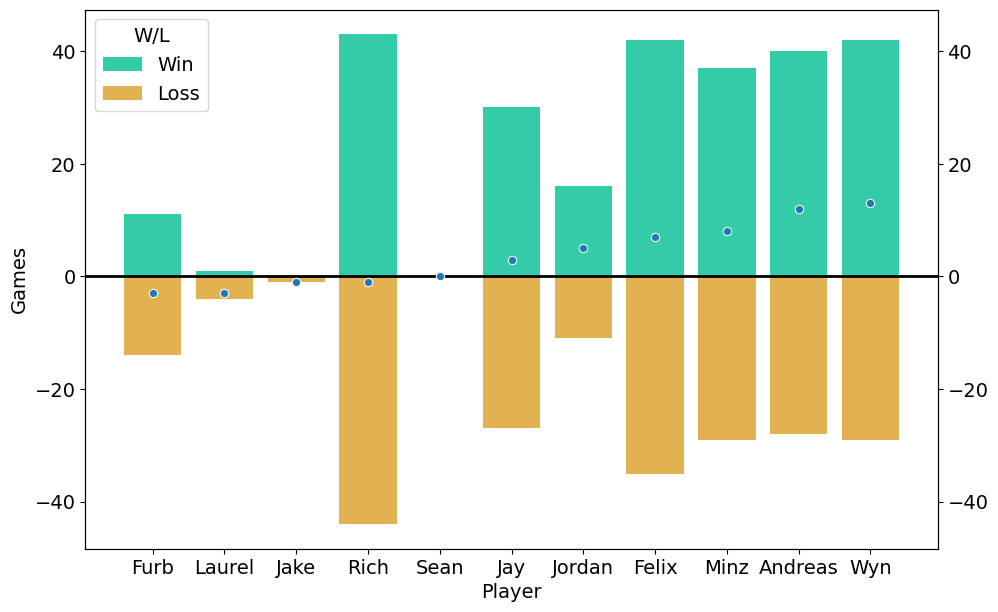

In [211]:
create_win_loss_plot(s14_3_wins_by_player, s14_3_games_by_player)

In [279]:
def _get_side_from_match(match: Match) -> Side:
    all_ids = [summoner.id for player in ALL_PLAYERS for summoner in player.summoners]
    participants: List[Participant] = match.participants
    for participant in participants:
        if participant.summoner.id in all_ids:
            return participant.side


def _find_n_synergies_on_team(participants: List[Participant], N: int):
    if N == 1:
        return [(ID_TO_PLAYER[p.summoner.id],) for p in participants if p.summoner.id in ID_TO_PLAYER]
    n_synergies = []
    for i, p in enumerate(participants):
        if p.summoner.id not in ID_TO_PLAYER:
            continue
        player = ID_TO_PLAYER[p.summoner.id]
        for combination_synergy in _find_n_synergies_on_team(participants[i + 1:], N - 1):
            n_synergies.append((player, *combination_synergy))
    n_synergies = [tuple(sorted(s, key=lambda x: x.id)) for s in n_synergies]
    return n_synergies
        

def get_n_synergy_win_loss_for_matches(matches: List[Match], N: int):
    wins_by_n_synergy = {}
    games_by_n_synergy = {}
    for match in matches:
        match: Match
        team = match.blue_team if _get_side_from_match(match) == Side.blue else match.red_team
        n_synergies = _find_n_synergies_on_team(list(team.participants), N=N)
        for n_synergy in n_synergies:
            if n_synergy not in wins_by_n_synergy:
                wins_by_n_synergy[n_synergy] = 0
                games_by_n_synergy[n_synergy] = 0
            games_by_n_synergy[n_synergy] += 1
            if team.win:
                wins_by_n_synergy[n_synergy] += 1

    wr_by_n_synergy = {s: wins_by_n_synergy[s] / games_by_n_synergy[s] for s in games_by_n_synergy.keys() if games_by_n_synergy[s] > 0}

    return wins_by_n_synergy, games_by_n_synergy, wr_by_n_synergy

In [331]:
s14_wins_by_duo, s14_games_by_duo, s14_wr_by_duo = get_n_synergy_win_loss_for_matches(s14_matches, N=2)
s14_wins_by_trio, s14_games_by_trio, s14_wr_by_trio = get_n_synergy_win_loss_for_matches(s14_matches, N=3)
s14_wins_by_four, s14_games_by_four, s14_wr_by_four = get_n_synergy_win_loss_for_matches(s14_matches, N=4)
s14_wins_by_five, s14_games_by_five, s14_wr_by_five = get_n_synergy_win_loss_for_matches(s14_matches, N=5)

In [386]:
def _create_win_loss_plots_from_wins_and_losses(wins, losses, player_groups, title: str):
    net_wins = [w - l for w, l in zip(wins, losses)]
    player_groups = [', '.join([str(p) for p in g]) for g in player_groups]

    bar_data = {
        'W/L': ['Win'] * len(player_groups) + ['Loss'] * len(player_groups),
        'Games': wins + [-l for l in losses],
        'Player': player_groups + player_groups}
    ax = sns.barplot(data=bar_data, x='Player', y='Games', hue='W/L', dodge=False, palette='turbo', order=player_groups)
    ax.axhline(0, lw=2, color='black')
    ax.tick_params(axis='x', rotation=75)
    ax.set_title(title)

    ax2 = ax.twinx()
    net_wins = [w - l for w, l in zip(wins, losses)]
    line_data = {
            'Net Wins': net_wins,
            'Player': [str(p) for p in player_groups]
    }
    sns.lineplot(data=line_data['Net Wins'], marker='o', ax=ax2, linestyle='')
    ax2.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1])

    plt.show()


def create_win_loss_plots_for_n_synergy(wins_by_n, games_by_n, title: str):
    n_synergies = list(wins_by_n.keys())

    sorted_wins = [wins_by_n[s] for s in n_synergies]
    sorted_losses = [games_by_n[s] - wins_by_n[s] for s in n_synergies]
    sorted_net_wins = [w - l for w, l in zip(sorted_wins, sorted_losses)]

    synergies_ordered_by_net_wins = sorted(n_synergies, key=lambda x: sorted_net_wins[n_synergies.index(x)], reverse=True)
    best_synergies = synergies_ordered_by_net_wins[:10]
    resorted_wins = [wins_by_n[s] for s in best_synergies]
    resorted_losses = [games_by_n[s] - wins_by_n[s] for s in best_synergies]
    _create_win_loss_plots_from_wins_and_losses(resorted_wins, resorted_losses, best_synergies, title=title.format("Best"))

    worst_synergies = list(reversed(synergies_ordered_by_net_wins))[:10]
    resorted_wins = [wins_by_n[s] for s in worst_synergies]
    resorted_losses = [games_by_n[s] - wins_by_n[s] for s in worst_synergies]
    _create_win_loss_plots_from_wins_and_losses(resorted_wins, resorted_losses, worst_synergies, title=title.format("Worst"))


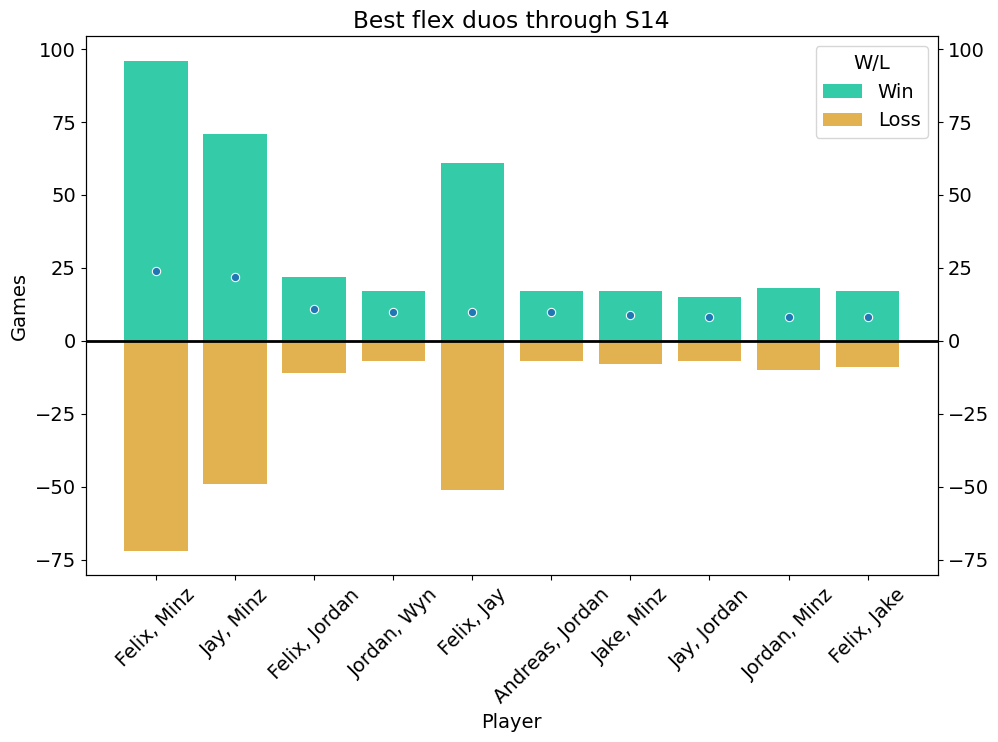

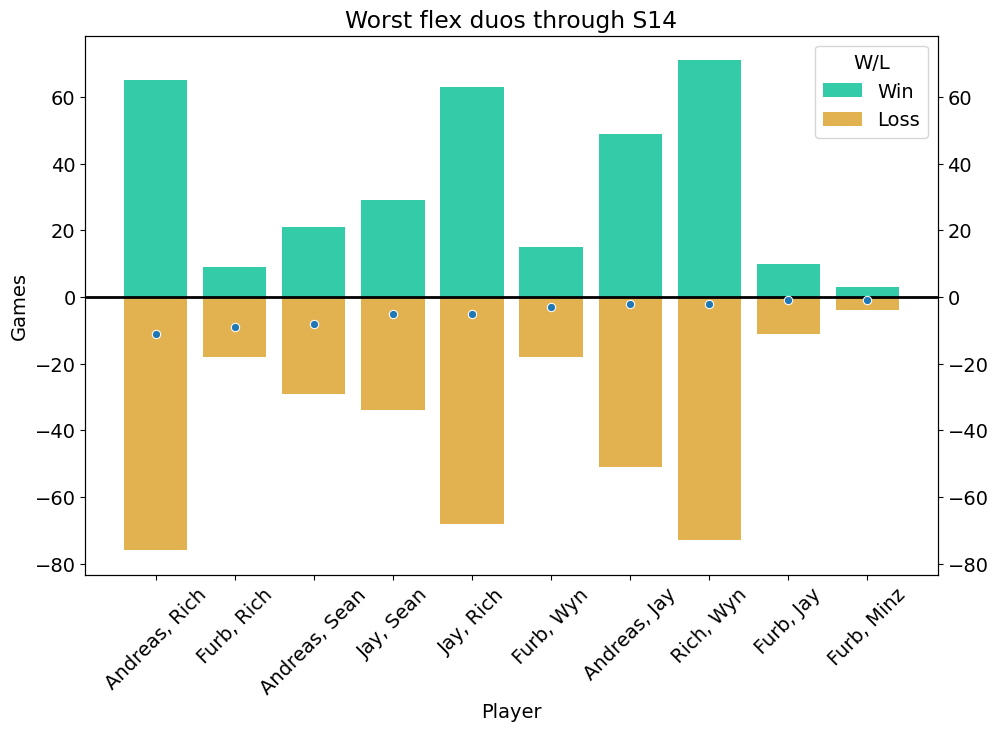

In [325]:
create_win_loss_plots_for_n_synergy(s14_wins_by_duo, s14_games_by_duo, title="{} flex duos through S14")

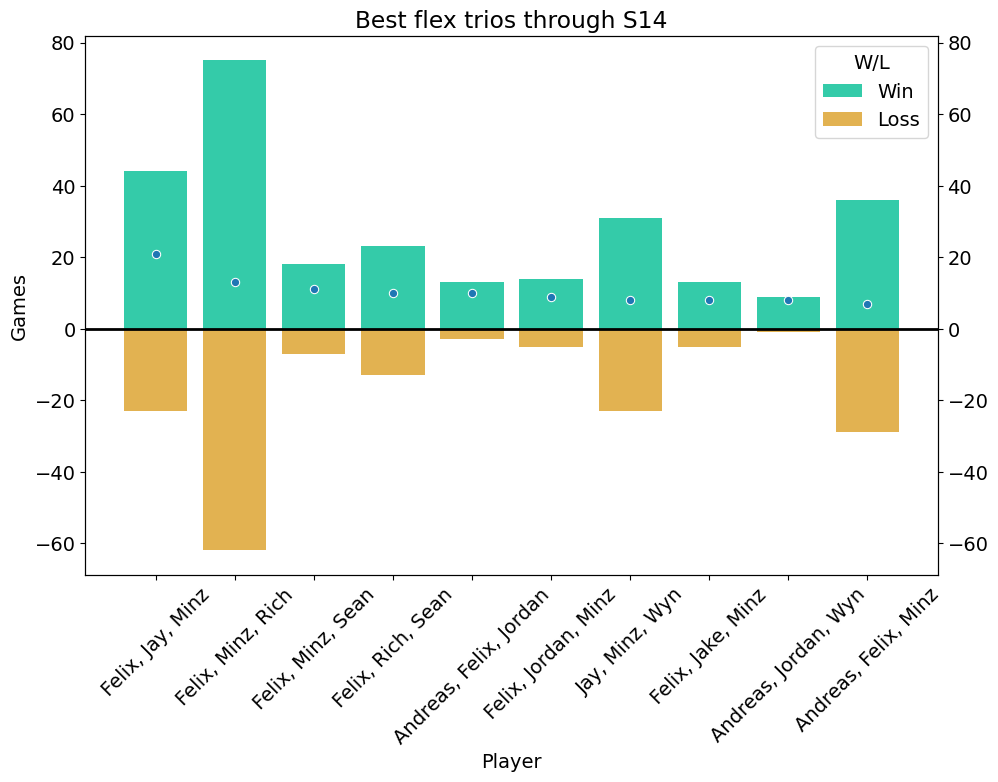

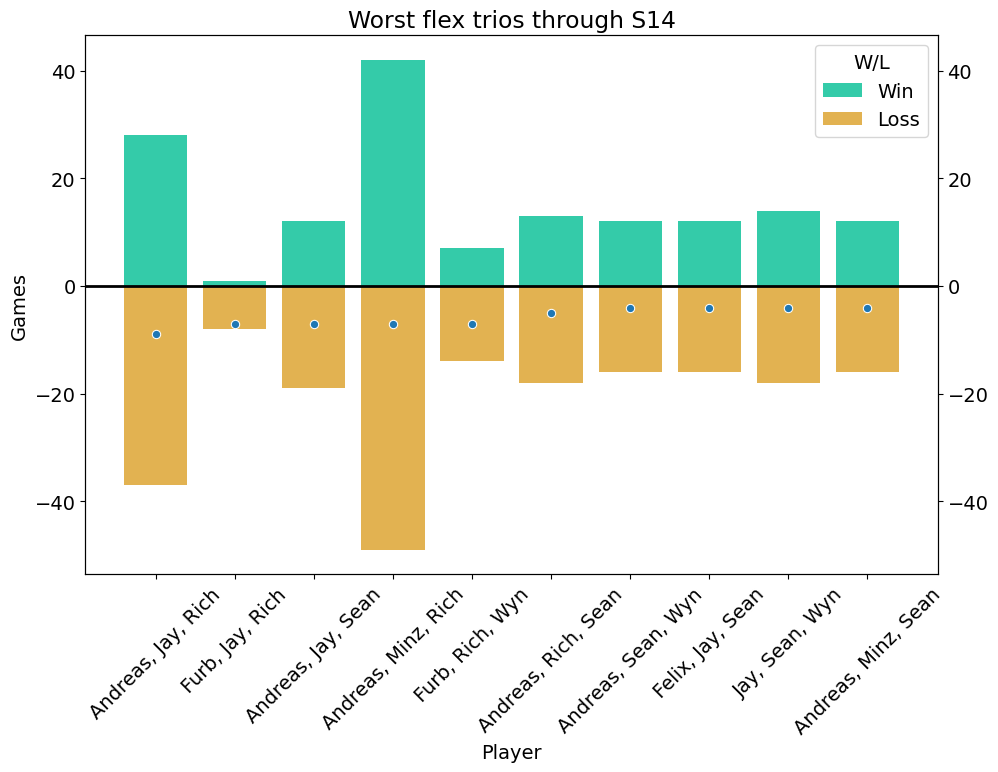

In [326]:
create_win_loss_plots_for_n_synergy(s14_wins_by_trio, s14_games_by_trio, title="{} flex trios through S14")

In [329]:
print(s14_wins_by_trio[(FURB, JAY, RICH)])
print(s14_games_by_trio[(FURB, JAY, RICH)])

1
9


In [330]:
print(s14_wins_by_trio[(ANDREAS, JORDAN, WYN)])
print(s14_games_by_trio[(ANDREAS, JORDAN, WYN)])

9
10


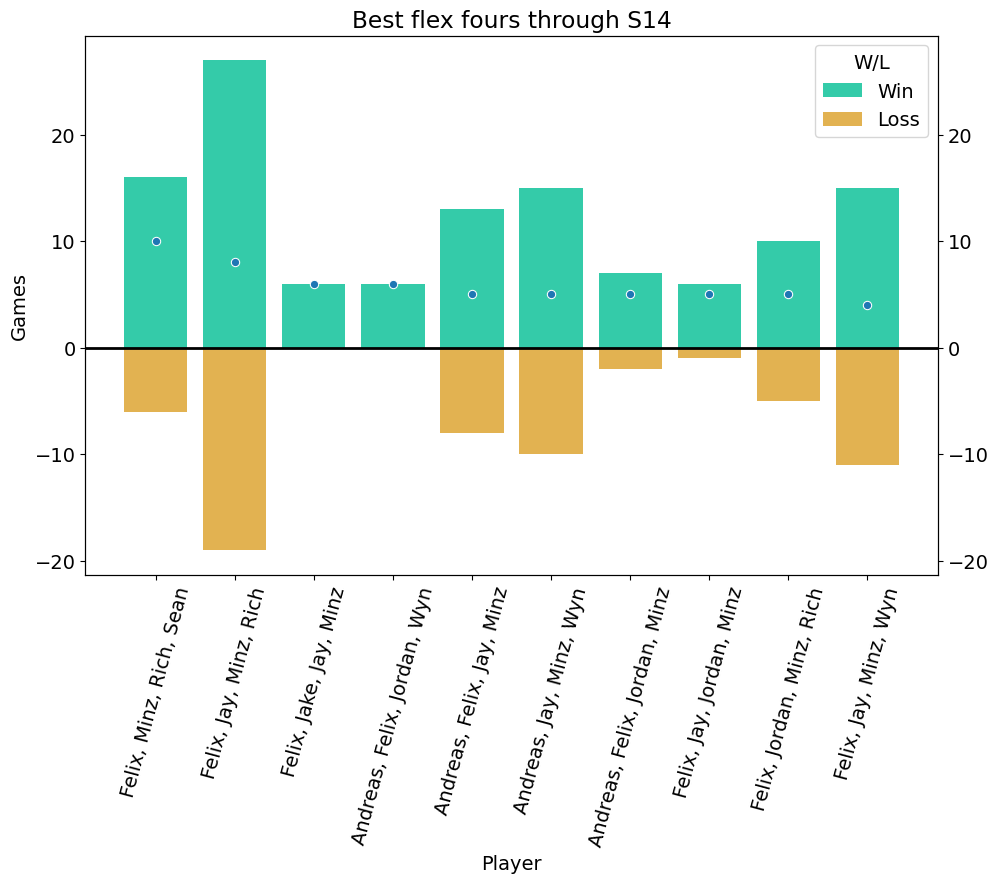

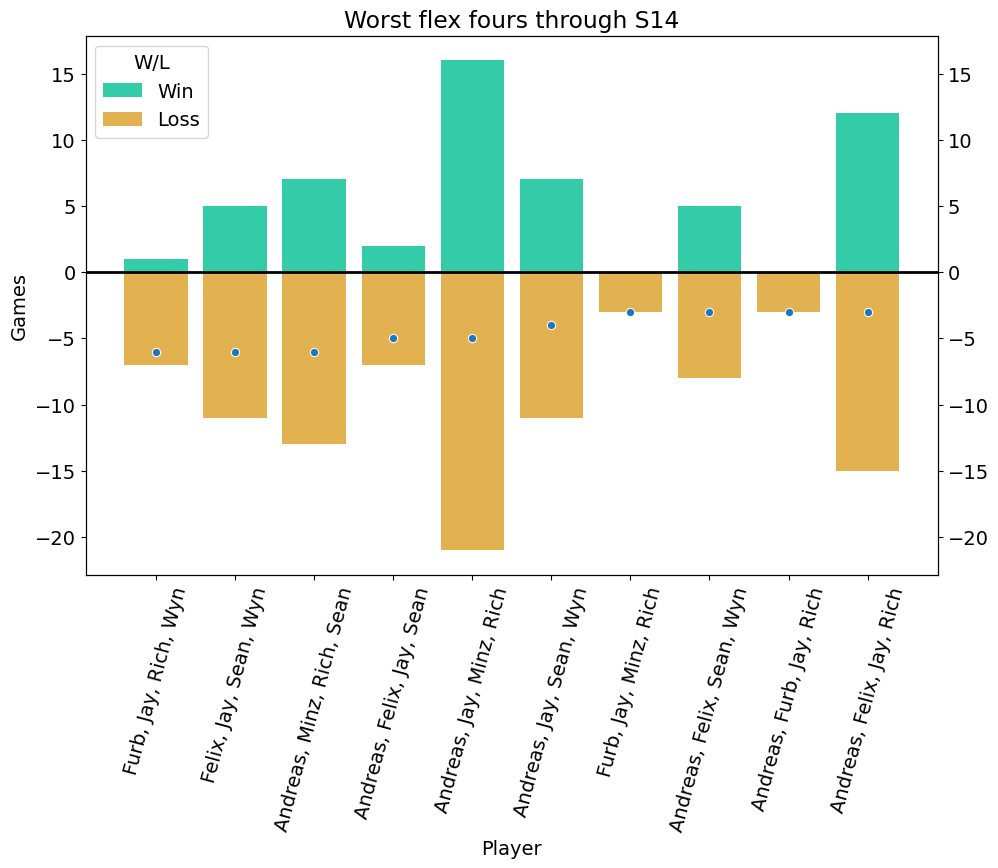

In [340]:
create_win_loss_plots_for_n_synergy(s14_wins_by_four, s14_games_by_four, title="{} flex fours through S14")

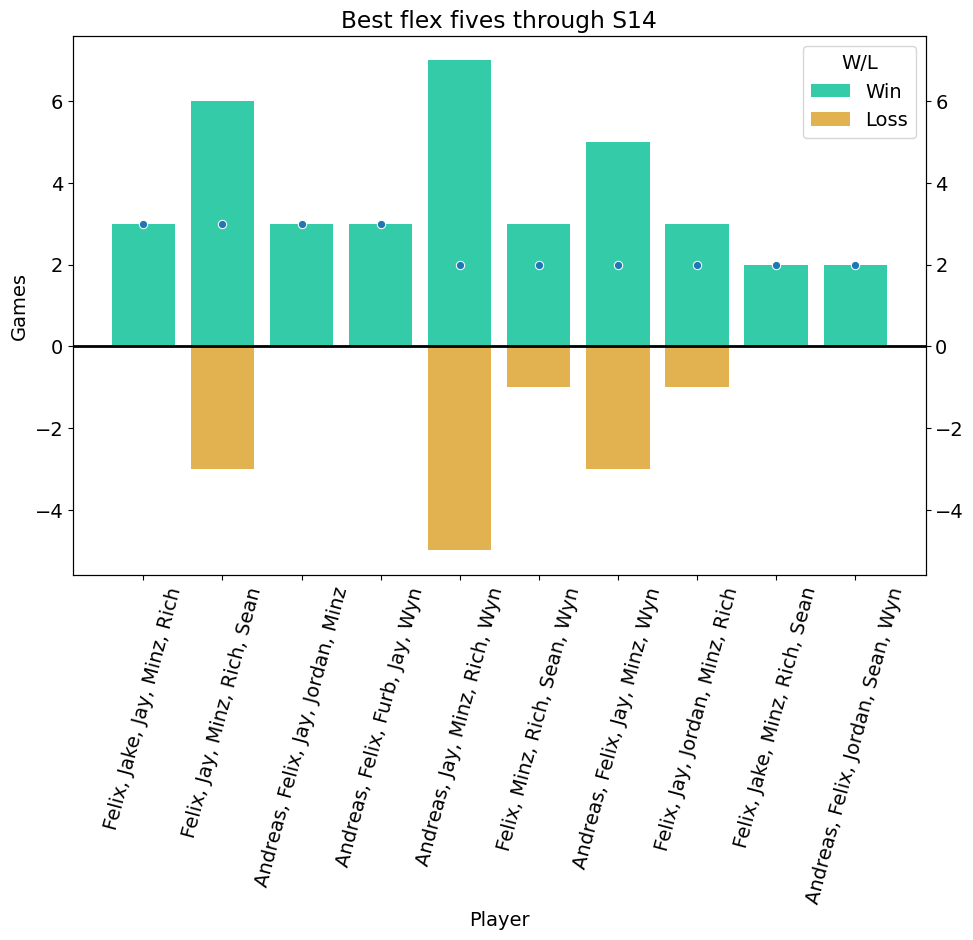

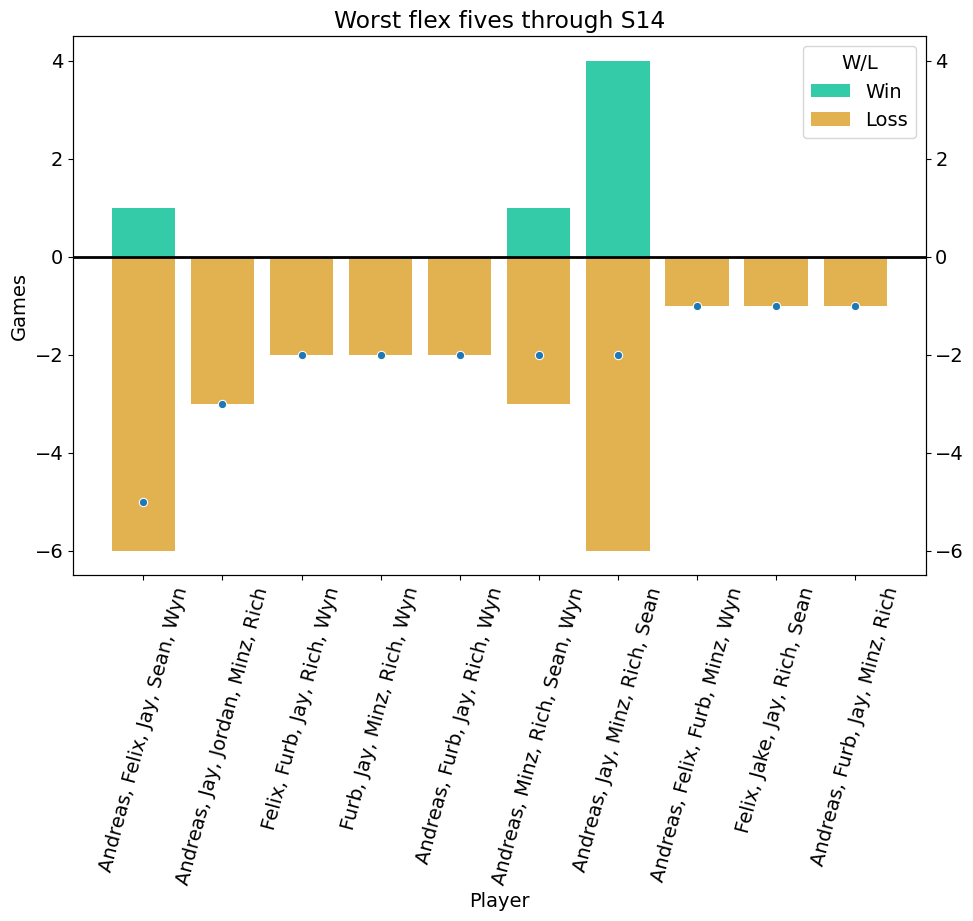

In [341]:
create_win_loss_plots_for_n_synergy(s14_wins_by_five, s14_games_by_five, title="{} flex fives through S14")

In [412]:
from cassiopeia.data import Lane


class Role(enum.Enum):
    TOP = "Top"
    MID = "Mid"
    JUNGLE = "Jung"
    BOT = "Bot"
    SUPPORT = "Supp"


LANE_TO_ROLE = {
    Lane.top_lane: Role.TOP,
    Lane.mid_lane: Role.MID,
    Lane.jungle: Role.JUNGLE,
    Lane.bot_lane: Role.BOT,
    Lane.utility: Role.SUPPORT,
}


class PlayerRole:
    player: Player
    role: Role

    def __init__(self, p, r):
        self.player = p
        self.role = r

    def __repr__(self):
        return f"{self.player.id} {self.role.value}"

    def __str__(self):
        return f"{self.player.id} {self.role.value}"
    
    def __eq__(self, x: "PlayerRole"):
        return self.player.id == x.player.id and self.role.value == x.role.value
    
    def __hash__(self):
        return str(self).__hash__()

In [413]:
def _find_n_synergies_by_role_on_team(participants: List[Participant], N: int):
    def _join_player_role(p: Participant):
        return PlayerRole(ID_TO_PLAYER[p.summoner.id], LANE_TO_ROLE[p.team_position])

    if N == 1:
        return [(_join_player_role(p),) for p in participants if p.summoner.id in ID_TO_PLAYER]
    n_synergies = []
    for i, p in enumerate(participants):
        if p.summoner.id not in ID_TO_PLAYER:
            continue
        for combination_synergy in _find_n_synergies_by_role_on_team(participants[i + 1:], N - 1):
            n_synergies.append((_join_player_role(p), *combination_synergy))
    n_synergies = [tuple(sorted(s, key=lambda x: x.player.id)) for s in n_synergies]
    return n_synergies


def get_n_synergy_by_role_win_loss_for_matches(matches: List[Match], N: int, min_games=10):
    wins_by_n_synergy = {}
    games_by_n_synergy = {}
    for match in matches:
        match: Match
        team = match.blue_team if _get_side_from_match(match) == Side.blue else match.red_team
        if match.is_remake:
            continue
        n_synergies = _find_n_synergies_by_role_on_team(list(team.participants), N=N)
        for n_synergy in n_synergies:
            if n_synergy not in wins_by_n_synergy:
                wins_by_n_synergy[n_synergy] = 0
                games_by_n_synergy[n_synergy] = 0
            games_by_n_synergy[n_synergy] += 1
            if team.win:
                wins_by_n_synergy[n_synergy] += 1

    if min_games:
        for n_synergy in games_by_n_synergy.keys():
            if games_by_n_synergy[n_synergy] < min_games:
                del games_by_n_synergy[n_synergy]
                del wins_by_n_synergy[n_synergy]
    wr_by_n_synergy = {s: wins_by_n_synergy[s] / games_by_n_synergy[s] for s in games_by_n_synergy.keys() if games_by_n_synergy[s] > 0}

    return wins_by_n_synergy, games_by_n_synergy, wr_by_n_synergy

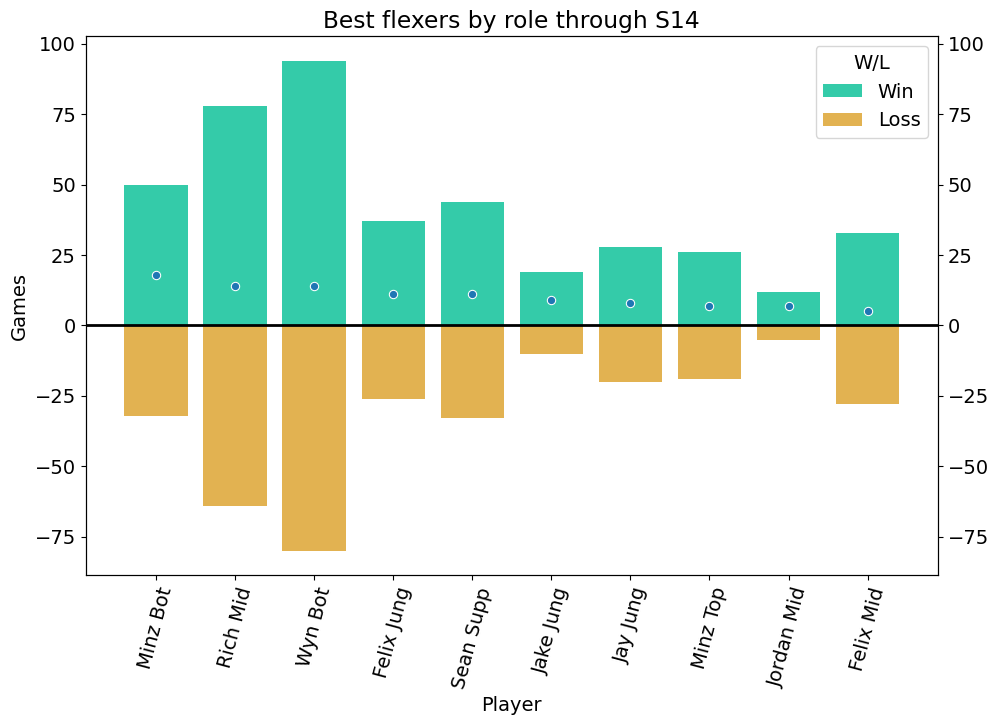

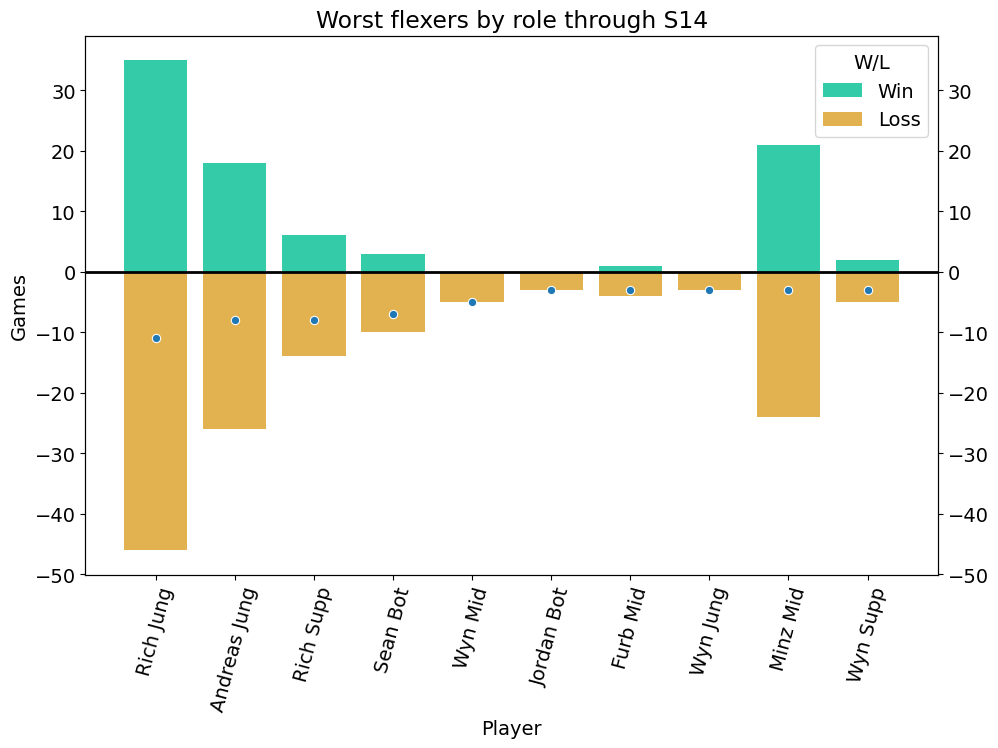

In [422]:
s14_w_by_role, s14_games_by_role, s14_wr_by_role = get_n_synergy_by_role_win_loss_for_matches(s14_matches, N=1)
create_win_loss_plots_for_n_synergy(s14_w_by_role, s14_games_by_role, title="{} flexers by role through S14")

In [438]:
ordered_wr_by_role = [(p, s14_wr_by_role[p]) for p in sorted(s14_wr_by_role.keys(), key=lambda x: s14_wr_by_role[x], reverse=True) if s14_games_by_role[p] > 10]
print("\n".join([f"{x[0][0]}, WR: {float(x[1])*100:2.2f}%, Games: {s14_games_by_role[x[0]]}" for x in ordered_wr_by_role]))

Jordan Mid, WR: 70.59%, Games: 17
Jake Jung, WR: 65.52%, Games: 29
Minz Bot, WR: 60.98%, Games: 82
Felix Jung, WR: 58.73%, Games: 63
Jay Jung, WR: 58.33%, Games: 48
Furb Supp, WR: 57.89%, Games: 19
Minz Top, WR: 57.78%, Games: 45
Sean Supp, WR: 57.14%, Games: 77
Andreas Supp, WR: 57.14%, Games: 14
Rich Mid, WR: 54.93%, Games: 142
Felix Mid, WR: 54.10%, Games: 61
Wyn Bot, WR: 54.02%, Games: 174
Andreas Mid, WR: 53.66%, Games: 41
Jordan Top, WR: 52.63%, Games: 19
Andreas Top, WR: 52.38%, Games: 84
Jay Supp, WR: 52.17%, Games: 46
Jay Bot, WR: 52.17%, Games: 23
Felix Supp, WR: 50.57%, Games: 87
Minz Jung, WR: 50.00%, Games: 56
Jay Top, WR: 50.00%, Games: 60
Rich Top, WR: 48.65%, Games: 37
Felix Top, WR: 47.73%, Games: 44
Minz Mid, WR: 46.67%, Games: 45
Minz Supp, WR: 45.45%, Games: 11
Rich Jung, WR: 43.21%, Games: 81
Furb Jung, WR: 41.67%, Games: 12
Andreas Jung, WR: 40.91%, Games: 44
Rich Supp, WR: 30.00%, Games: 20
Sean Bot, WR: 23.08%, Games: 13


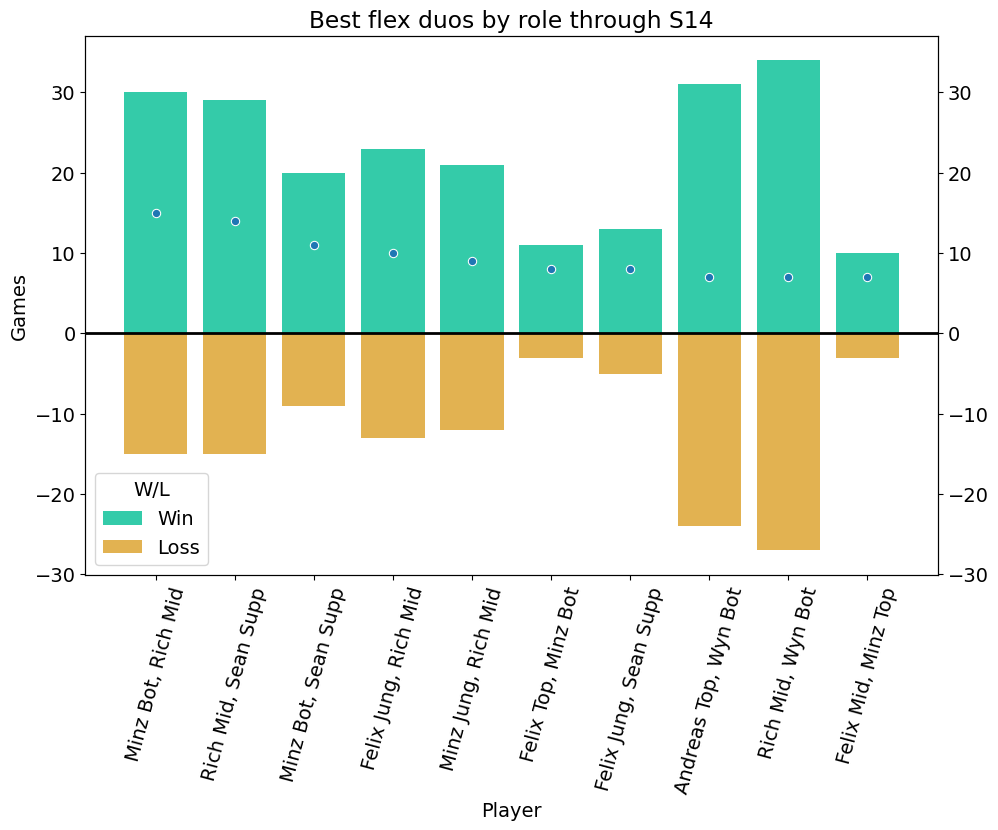

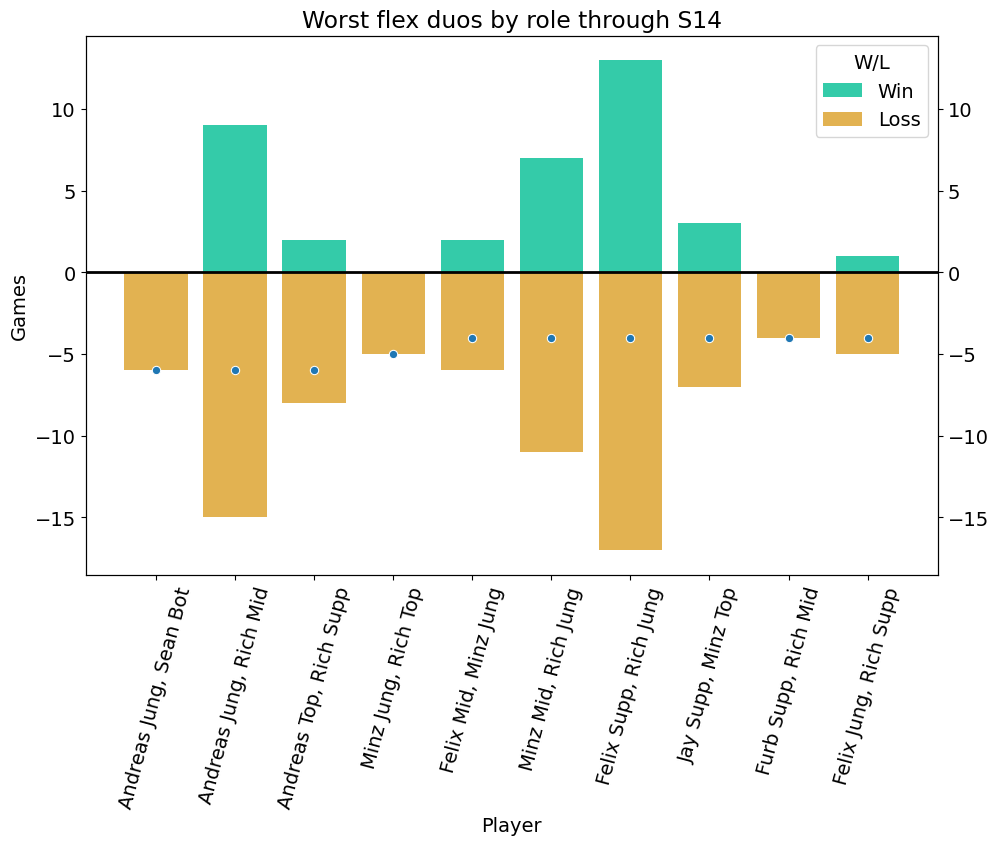

In [439]:
s14_wins_by_duo_by_role, s14_games_by_by_duo_by_role, s14_wr_by_by_duo_by_role = get_n_synergy_by_role_win_loss_for_matches(s14_matches, N=2)
create_win_loss_plots_for_n_synergy(s14_wins_by_duo_by_role, s14_games_by_by_duo_by_role, title="{} flex duos by role through S14")

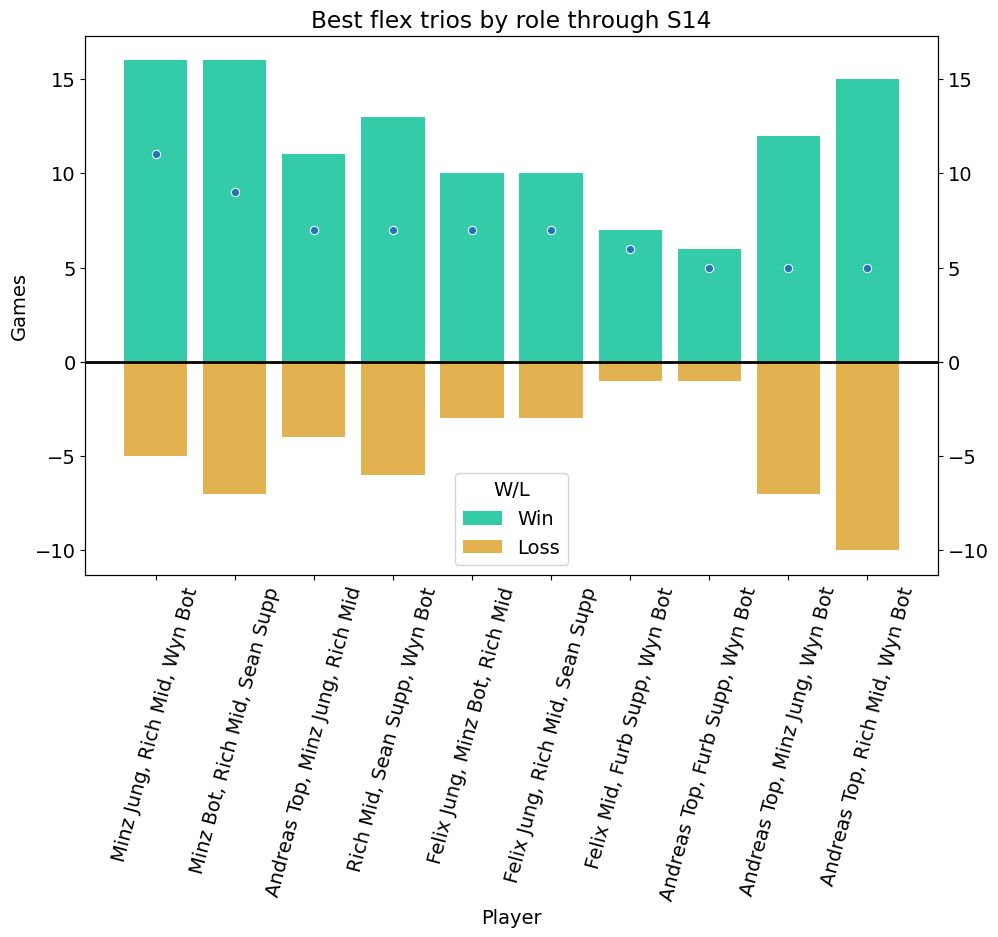

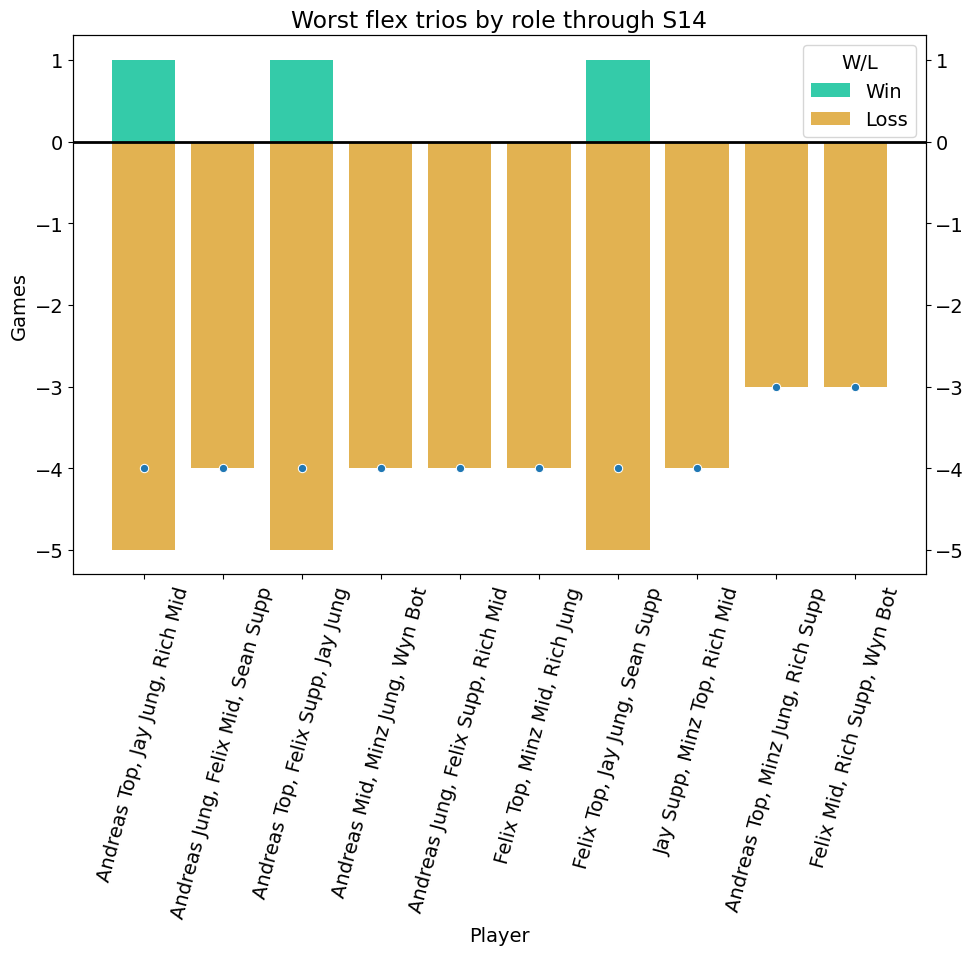

In [416]:
s14_wins_by_trio_by_role, s14_games_by_by_trio_by_role, s14_wr_by_by_trio_by_role = get_n_synergy_by_role_win_loss_for_matches(s14_matches, N=3)
create_win_loss_plots_for_n_synergy(s14_wins_by_trio_by_role, s14_games_by_by_trio_by_role, title="{} flex trios by role through S14")

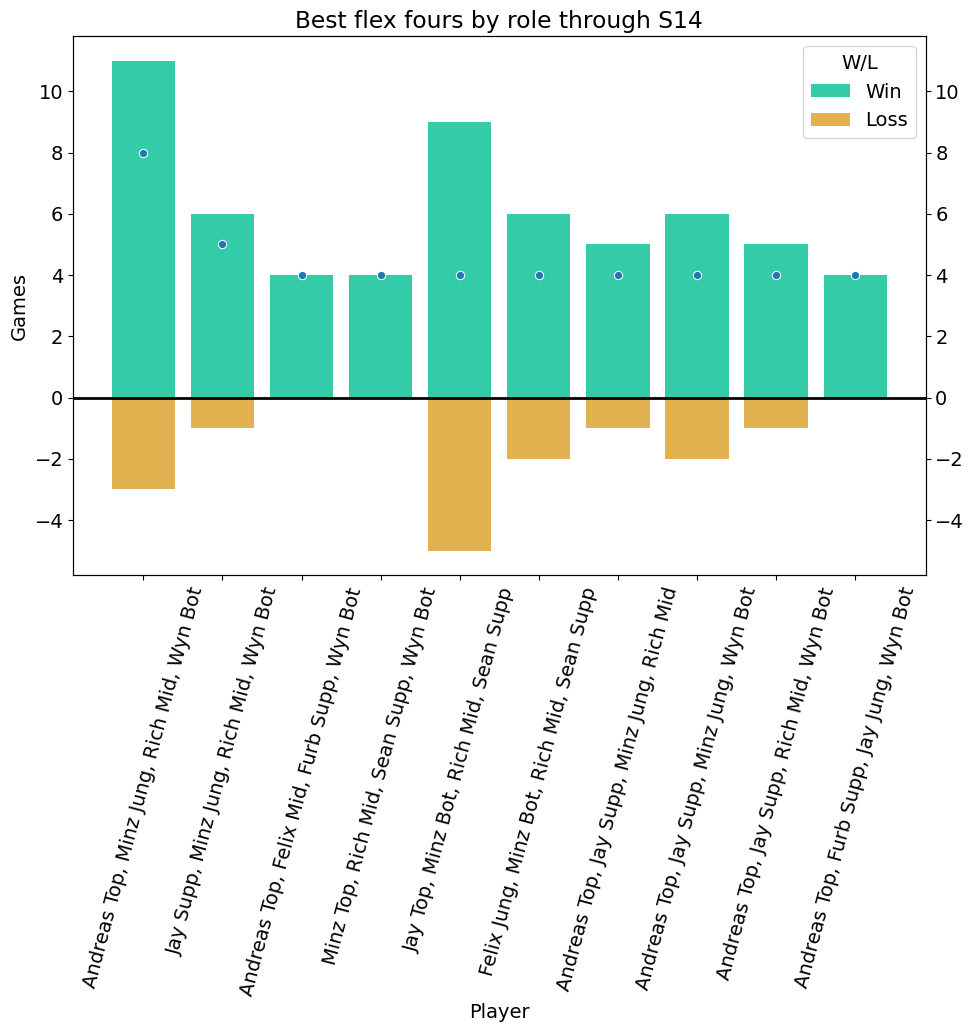

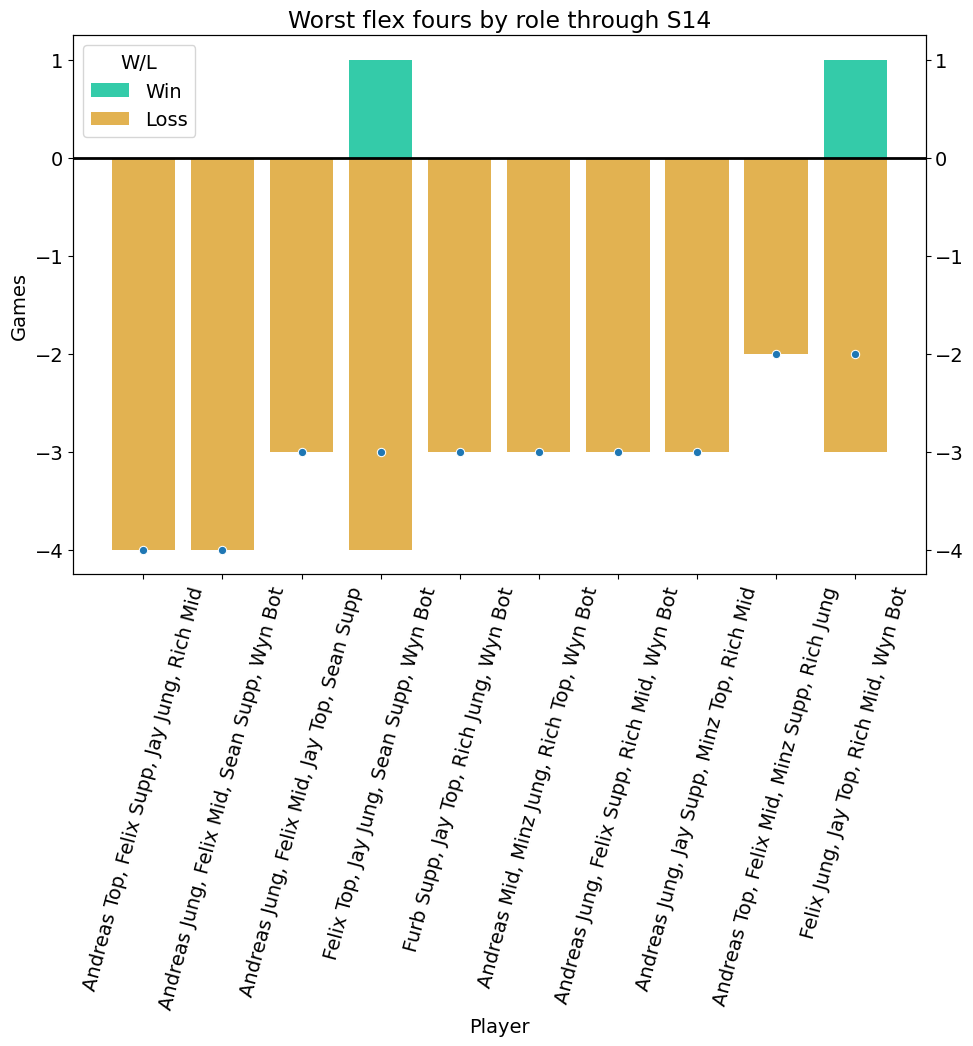

In [417]:
s14_wins_by_four_by_role, s14_games_by_by_four_by_role, s14_wr_by_by_four_by_role = get_n_synergy_by_role_win_loss_for_matches(s14_matches, N=4)
create_win_loss_plots_for_n_synergy(s14_wins_by_four_by_role, s14_games_by_by_four_by_role, title="{} flex fours by role through S14")

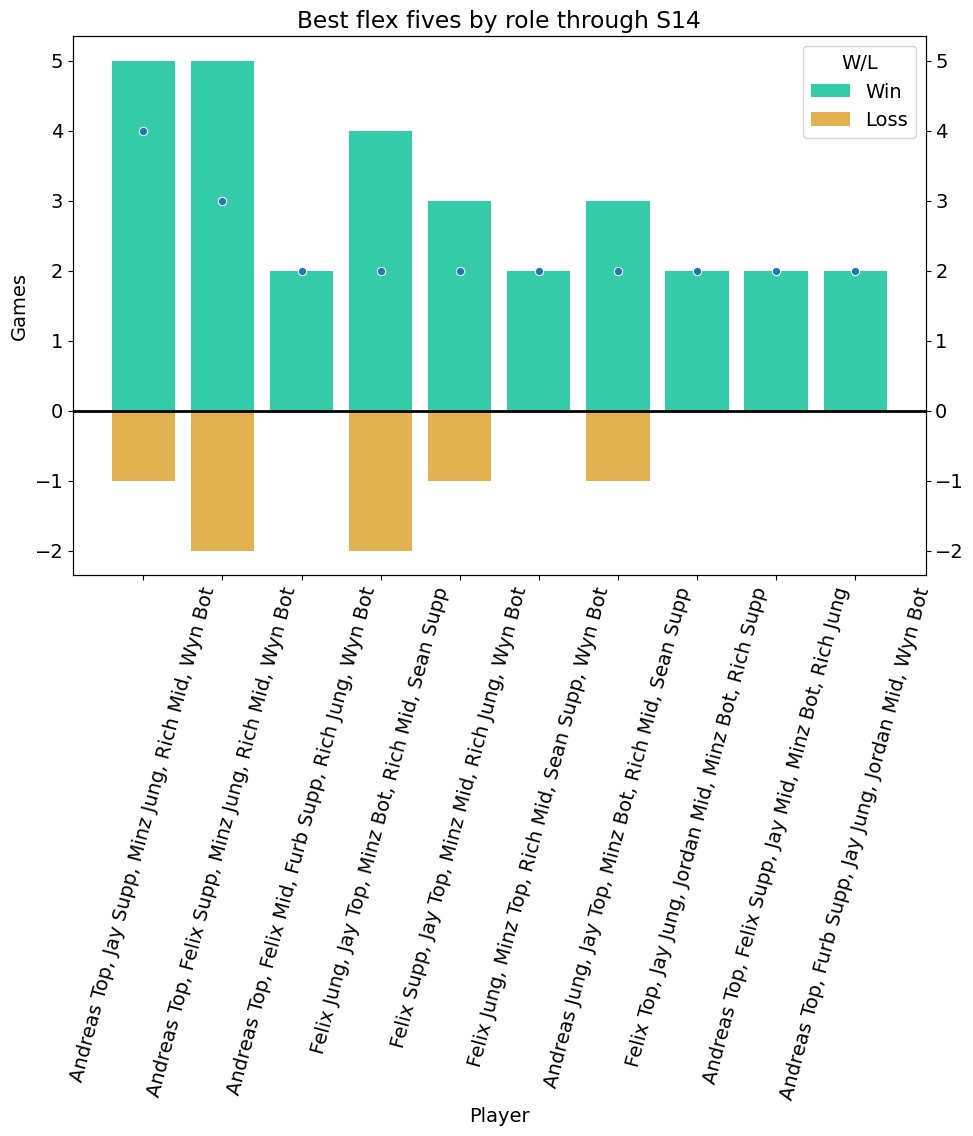

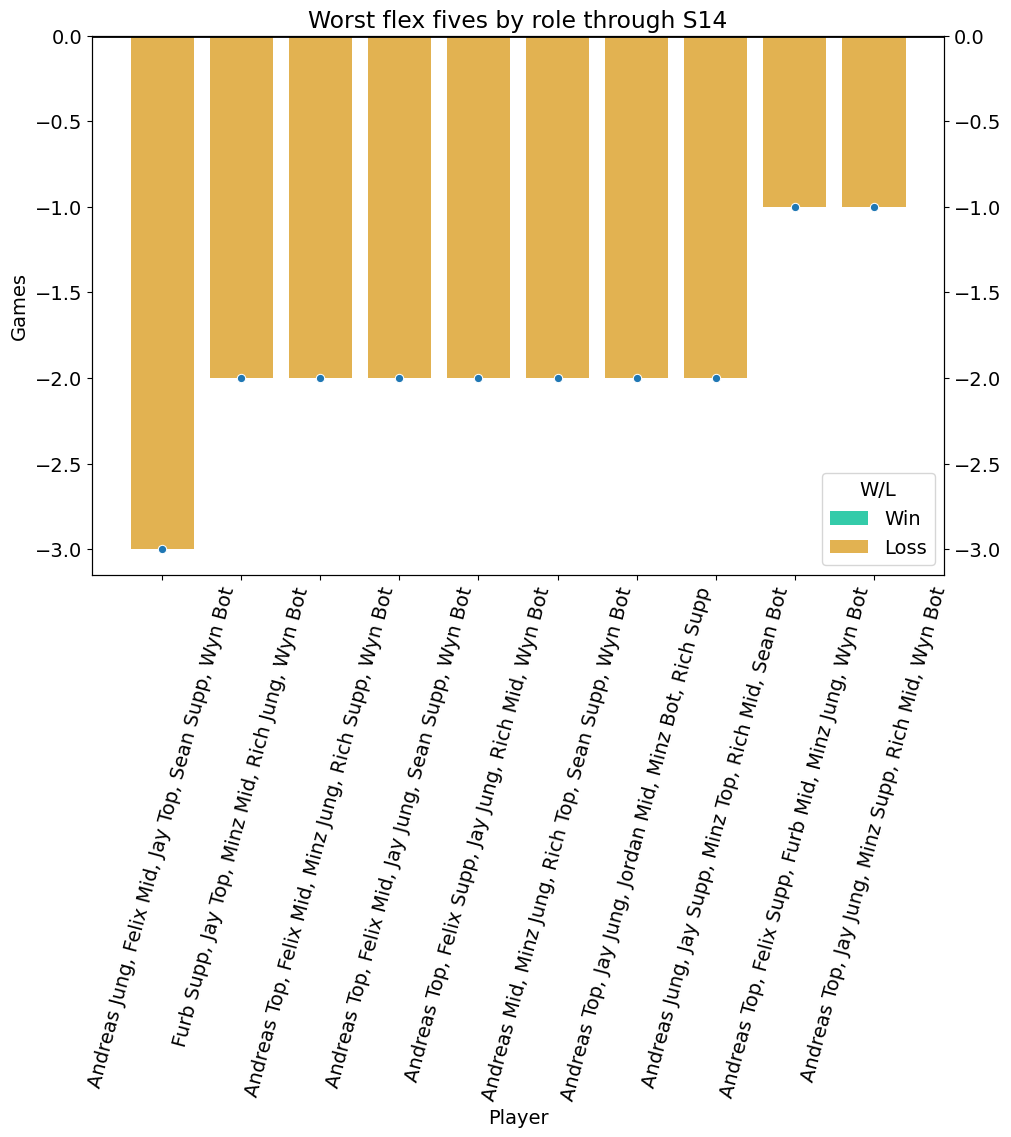

In [418]:
s14_wins_by_five_by_role, s14_games_by_by_five_by_role, s14_wr_by_by_five_by_role = get_n_synergy_by_role_win_loss_for_matches(s14_matches, N=5)
create_win_loss_plots_for_n_synergy(s14_wins_by_five_by_role, s14_games_by_by_five_by_role, title="{} flex fives by role through S14")